In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


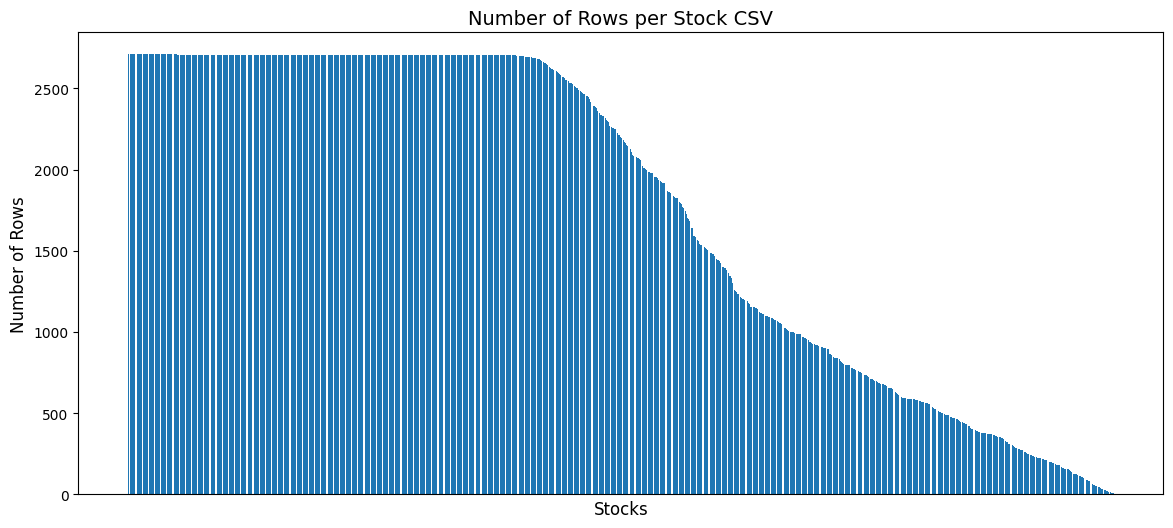

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 📂 Path to your folder
folder_path = "/content/drive/MyDrive/NSE"   # change to your folder path

# Collect row counts
row_counts = {}
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

for file in csv_files:
    file_path = os.path.join(folder_path, file)
    try:
        row_count = sum(1 for _ in open(file_path)) - 1  # exclude header
        stock_name = os.path.splitext(file)[0]          # filename without .csv
        row_counts[stock_name] = row_count
    except Exception as e:
        print(f"⚠️ Error reading {file}: {e}")

# Convert to DataFrame
df = pd.DataFrame(list(row_counts.items()), columns=["Stock", "Rows"])

# Sort by number of rows
df = df.sort_values(by="Rows", ascending=False).reset_index(drop=True)

# 📊 Plot
plt.figure(figsize=(14, 6))
plt.bar(df["Stock"], df["Rows"])
plt.xlabel("Stocks", fontsize=12)
plt.ylabel("Number of Rows", fontsize=12)
plt.title("Number of Rows per Stock CSV", fontsize=14)
plt.xticks([], [])  # Hide stock names (too many to show), remove if you want
plt.show()


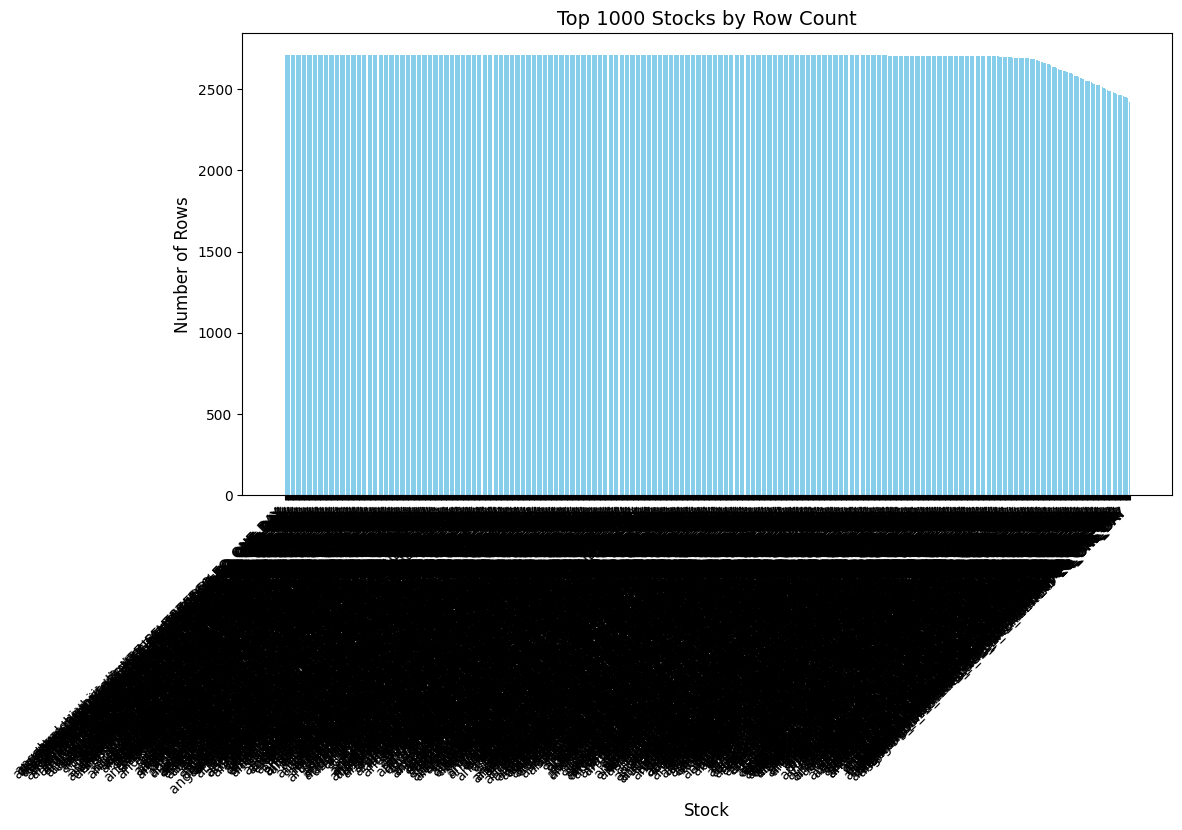

In [ ]:
top_n = 1000
top_df = df.head(top_n)

plt.figure(figsize=(12, 6))
plt.bar(top_df["Stock"], top_df["Rows"], color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Stock", fontsize=12)
plt.ylabel("Number of Rows", fontsize=12)
plt.title(f"Top {top_n} Stocks by Row Count", fontsize=14)
plt.show()


In [ ]:
import os
import pandas as pd

# 📂 Path to your folder containing CSV files
folder_path = "/content/drive/MyDrive/NSE"   # change to your folder path

csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]
print(f"📁 Found {len(csv_files)} CSV files\n")

total_rows = 0

for file in csv_files:
    file_path = os.path.join(folder_path, file)
    try:
        row_count = sum(1 for _ in open(file_path)) - 1  # excluding header
        print(f"{file} --> {row_count} rows")
        total_rows += row_count
    except Exception as e:
        print(f"⚠️ Error reading {file}: {e}")

print(f"\n✅ Total CSV files: {len(csv_files)}")
print(f"📊 Total rows across all files: {total_rows}")


📁 Found 2133 CSV files

angelone_historical3_NSE_AMNPLST-EQ_ONE_DAY.csv --> 434 rows
angelone_historical3_NSE_LGHL-EQ_ONE_DAY.csv --> 479 rows
angelone_historical3_NSE_RADIOCITY-EQ_ONE_DAY.csv --> 2075 rows
angelone_historical3_NSE_ESAFSFB-EQ_ONE_DAY.csv --> 376 rows
angelone_historical3_NSE_MASFIN-EQ_ONE_DAY (1).csv --> 1937 rows
angelone_historical3_NSE_MASFIN-EQ_ONE_DAY.csv --> 1937 rows
angelone_historical3_NSE_DMART-EQ_ONE_DAY.csv --> 2080 rows
angelone_historical3_NSE_ORISSAMINE-EQ_ONE_DAY.csv --> 2708 rows
angelone_historical3_NSE_EGOLD-EQ_ONE_DAY.csv --> 376 rows
angelone_historical3_NSE_DEEPAKNTR-EQ_ONE_DAY.csv --> 2708 rows
angelone_historical3_NSE_LICHSGFIN-EQ_ONE_DAY.csv --> 2708 rows
angelone_historical3_NSE_AHLADA-EQ_ONE_DAY.csv --> 1125 rows
angelone_historical3_NSE_SASTASUNDR-EQ_ONE_DAY.csv --> 2707 rows
angelone_historical3_NSE_INTENTECH-EQ_ONE_DAY.csv --> 2076 rows
angelone_historical3_NSE_INFRABEES-EQ_ONE_DAY.csv --> 2707 rows
angelone_historical3_NSE_CPCAP-EQ_ONE_DA

In [ ]:
str=csv_files[13]
s=str[52:]
print (str)
clean_name = s.replace("-EQ_ONE_DAY.csv", "")
print(clean_name)

/content/drive/MyDrive/NSE/angelone_historical3_NSE_DEEPAKNTR-EQ_ONE_DAY.csv
DEEPAKNTR


In [ ]:
import os

folder_path = "/content/drive/MyDrive/NSE"
num_files = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])

print("Number of files:", num_files)


Number of files: 2135


In [ ]:
import os
import glob
import pandas as pd

# 🔹 Path to folder containing all stock CSVs
folder_path = "/content/drive/MyDrive/NSE"   # change to your folder

# 🔹 Get list of all CSV files
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# 🔹 Empty list to hold DataFrames
df_list = []

for file in csv_files:
    s=file[52:]
    stock_id = s.replace("-EQ_ONE_DAY.csv", "")

    # Read CSV
    df = pd.read_csv(file)

    # Add stock_id column
    df["stock_id"] = stock_id
    print(stock_id)
    # Append to list
    df_list.append(df)

# 🔹 Combine all into one DataFrame
all_stocks_df = pd.concat(df_list, ignore_index=True)

# 🔹 Sort by stock_id + date (important for time series)
all_stocks_df["date"] = pd.to_datetime(all_stocks_df["date"])
all_stocks_df = all_stocks_df.sort_values(by=["stock_id", "date"])

print("Shape of combined dataset:", all_stocks_df.shape)
print(all_stocks_df.head())


AMNPLST
LGHL
RADIOCITY
ESAFSFB
MASFIN-EQ_ONE_DAY (1).csv
MASFIN
DMART
ORISSAMINE
EGOLD
DEEPAKNTR
LICHSGFIN
AHLADA
SASTASUNDR
INTENTECH
INFRABEES
CPCAP
TASTYBITE
UNIDT
GREENPOWER
RAMKY
ASKAUTOLTD
ARIHANTSUP
CANTABIL
AKSHARCHEM
LUMAXIND
ASHOKA
WABAG
BEDMUTHA
URJA
CLEDUCATE
JWL
OBEROIRLTY
IREDA
ESILVER
LYKALABS
IRFC
TATATECH
ASHAPURMIN
PRESTIGE
GANDHAR
M&M
FEDFINA
SHANKARA
RESPONIND
CGCL
FLAIR
COALINDIA
IOLCP
RAMCOCEM
INDIGOPNTS
WIPL
CHENNPETRO
PRUDMOULI
AXISGOLD
GRAVITA
BBNPPGOLD
DOMS
INDIASHLTR
HOMEFIRST
DOLLAR
ASHIMASYN
INOXINDIA
SUPERHOUSE
PENIND
JINDWORLD
SCHAND
VTL
RPPINFRA
JAMNAAUTO
SURAJEST
MOTISONS
HUDCO
MOIL
MUTHOOTMF
MAHSCOOTER
HAPPYFORGE
RBZJEWEL
MUFTI
PSPPROJECT
MAHSEAMLES
AZAD
KIRLOSENG
RKDL
SUNCLAY
PSB
FMNL
INNOVACAP
MANGLMCEM
STOVEKRAFT
SURANASOL
STARCEMENT
SHEKHAWATI
BFINVEST
KICL
MARALOVER
TEJASNET
ERIS
CDSL
GTPL
ASHOKLEY
AUBANK
MASTEK-EQ_ONE_DAY (1).csv
MASTEK
DIGIDRIVE
AXISNIFTY
LOWVOLIETF
SUMMITSEC
JYOTICNC
DYNPRO
STEELXIND
SALASAR
PALASHSECU
MAGADSUGAR
GANGESSECU
TAT

In [ ]:
df=all_stocks_df

In [ ]:
len(df)

3752966

In [ ]:
# check total nulls in each column
print(df.isnull().sum())


date                                   0
open                                   0
high                                   0
low                                    0
close                                  0
Total traded quantity (volume)         0
SMMA_5                              8532
SMMA_20                            40430
SMMA_40                            82649
SMMA_150                          310351
SMMA_diff_5_20                     40430
SMMA_diff_20_40                    82649
SMMA_diff_40_150                  310351
stock_id                               0
dtype: int64


In [ ]:
indicator_cols = [
    'SMMA_5', 'SMMA_20', 'SMMA_40', 'SMMA_150',
    'SMMA_diff_5_20', 'SMMA_diff_20_40', 'SMMA_diff_40_150'
]

# First forward fill (propagate last valid value downwards)
df[indicator_cols] = df[indicator_cols].ffill()

# Then backward fill (fill remaining NaNs at the top with next valid value)
df[indicator_cols] = df[indicator_cols].bfill()

# Check if any nulls remain
print(df[indicator_cols].isnull().sum())

SMMA_5              0
SMMA_20             0
SMMA_40             0
SMMA_150            0
SMMA_diff_5_20      0
SMMA_diff_20_40     0
SMMA_diff_40_150    0
dtype: int64


In [ ]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

In [ ]:
df = df.drop_duplicates()


**Calculation**

Target takes the next day’s closing price and assigns it to today’s row.
Target_Return= (Target−TodayClose)/TodayClose

This converts returns into movement classes:

1 → if Target_Return > 0 (price goes up)

-1 → if Target_Return < 0 (price goes down)

0 → if no change

Remaps movement into a 3-class classification target:

-1 → 0 (Down)

0 → 1 (No Change)

1 → 2 (Up)


	​


In [ ]:
# Create Target column (next day's close)
df['target'] = df['close'].shift(-1)

# Calculate Target Return
df['Target_Return'] = (df['target'] - df['close']) / df['close']

# Define Target Movement (1 = up, -1 = down, 0 = no change)
df['Target_Movement'] = df['Target_Return'].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
df["Target_Movement"] = df["Target_Movement"].map({-1: 0, 0: 1, 1: 2})
# Last row will have NaN since there's no "next day"
print(df.head())

              date    open    high     low   close  \
3600190 2014-07-15   22.07   22.38   21.83   21.98   
1583794 2014-07-15   71.70   73.35   69.40   72.40   
1637508 2014-07-15  244.57  245.58  238.04  244.39   
1606751 2014-07-15  612.50  639.00  612.50  621.35   
3719206 2014-07-15   92.40   94.50   92.00   93.25   

         Total traded quantity (volume)       SMMA_5      SMMA_20  \
3600190                           57209    21.888364    22.520851   
1583794                         3268142     1.542674     1.596860   
1637508                         1958739   902.536906   929.639367   
1606751                             110  1756.813636  1726.298163   
3719206                          277179    62.601271    65.474882   

             SMMA_40     SMMA_150  SMMA_diff_5_20  SMMA_diff_20_40  \
3600190    23.347679    28.258323       -0.632487        -0.826828   
1583794     1.618020     1.909342       -0.054186        -0.021160   
1637508   938.478024   999.408980      -27.102461 

In [ ]:
df = df.drop(df.index[-1])
df.isnull().sum()

,0
date,0
open,0
high,0
low,0
close,0
Total traded quantity (volume),0
SMMA_5,0
SMMA_20,0
SMMA_40,0
SMMA_150,0


In [ ]:
df.head(100)

,date,open,high,low,close,Total traded quantity (volume),SMMA_5,SMMA_20,SMMA_40,SMMA_150,SMMA_diff_5_20,SMMA_diff_20_40,SMMA_diff_40_150,stock_id,target,Target_Return,Target_Movement
3600190,2014-07-15,22.07,22.38,21.83,21.98,57209,21.888364,22.520851,23.347679,28.258323,-0.632487,-0.826828,-4.910645,VISAKAIND,72.40,2.293904,2
1583794,2014-07-15,71.70,73.35,69.40,72.40,3268142,1.542674,1.596860,1.618020,1.909342,-0.054186,-0.021160,-0.291322,IOB,244.39,2.375552,2
1637508,2014-07-15,244.57,245.58,238.04,244.39,1958739,902.536906,929.639367,938.478024,999.408980,-27.102461,-8.838657,-60.930957,HAVELLS,621.35,1.542453,2
1606751,2014-07-15,612.50,639.00,612.50,621.35,110,1756.813636,1726.298163,1644.339005,1377.758442,30.515473,81.959159,266.580563,ESABINDIA,93.25,-0.849924,0
3719206,2014-07-15,92.40,94.50,92.00,93.25,277179,62.601271,65.474882,65.986724,61.917948,-2.873611,-0.511842,4.068776,NLCINDIA,38.95,-0.582306,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1545199,2014-07-16,9.05,9.90,9.05,9.60,1788,5.907351,5.885377,5.885306,6.065198,0.021974,0.000071,-0.179892,UMIYA-MRO,51.38,4.352083,2
1634801,2014-07-16,51.85,52.90,50.90,51.38,155288,1877.044857,1842.441287,1831.773592,1741.300123,34.603570,10.667695,90.473469,EPL,163.33,2.178863,2
3697130,2014-07-16,158.84,165.99,158.84,163.33,413151,275.230813,287.498301,281.200306,286.180748,-12.267488,6.297995,-4.980442,DEEPAKFERT,220.18,0.348068,2
3649732,2014-07-16,222.40,228.60,219.00,220.18,150824,305.664515,287.833813,284.361361,287.832008,17.830702,3.472452,-3.470647,ZYDUSLIFE,339.95,0.543964,2


In [ ]:
df.to_csv('/content/drive/MyDrive/NSE/all_stocks.csv', index=False)

Using IncrementalPCA (large dataset).
Explained Variance Ratio (Incremental PCA): approx not available directly
Fitting UMAP on 20000 samples (this may take a while)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


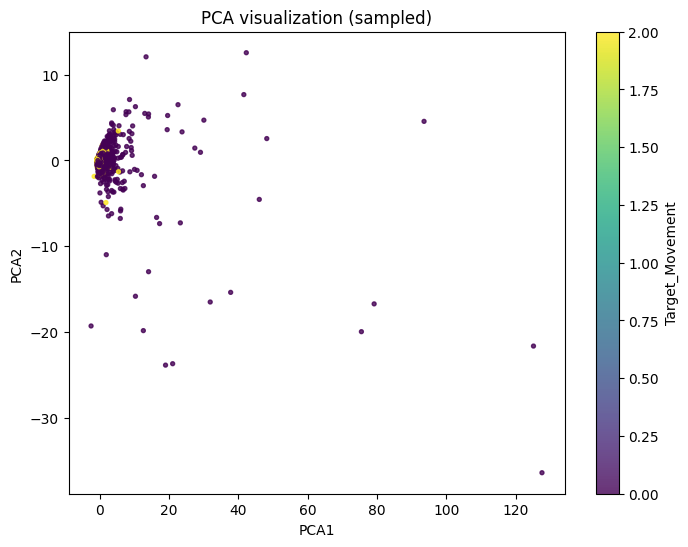

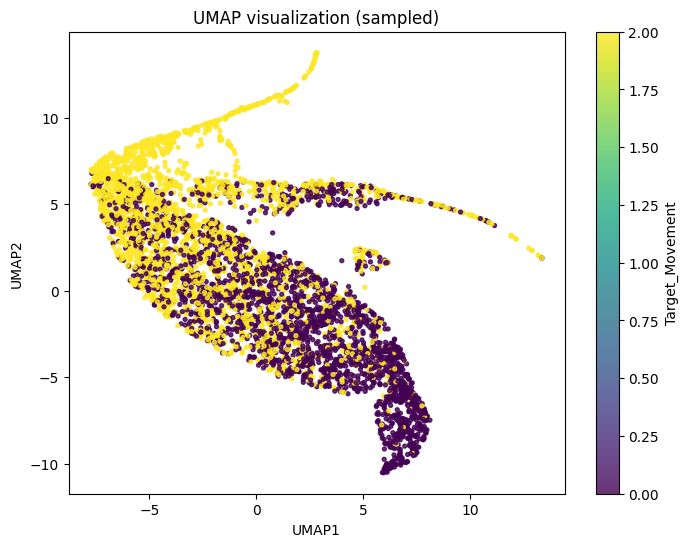

In [ ]:
import numpy as np
import pandas as pd
import gc
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA, IncrementalPCA
import umap.umap_ as umap
import matplotlib.pyplot as plt


PCA_COMPONENTS = 3
UMAP_COMPONENTS = 2
UMAP_SAMPLE_SIZE = 20000       # fit UMAP on this many rows max
PLOT_SAMPLE = 5000             # plot only this many points to avoid renderer overload
IPCA_BATCH_SIZE = 5000         # batch size for IncrementalPCA (tune to memory)

# ---------------------------
# Prepare numeric feature matrix (drop non-numeric / label cols)
# ---------------------------
# Make a copy to avoid modifying original df accidentally
_work = df.copy()

# Ensure date and id/label columns are removed
cols_to_drop = ["date", "target", "Target_Movement", "stock_id"]
cols_to_drop = [c for c in cols_to_drop if c in _work.columns]
X_df = _work.drop(columns=cols_to_drop)

# Keep only numeric columns (safe)
X_df = X_df.select_dtypes(include=[np.number])

# ---------------------------
# Impute missing values and remove zero-variance columns
# ---------------------------
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_df)   # numpy array

# Remove zero-variance features (VarianceThreshold)
vt = VarianceThreshold(threshold=0.0)
X_non_const = vt.fit_transform(X_imputed)

# ---------------------------
# Scale features
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_non_const)

# Free memory
del X_imputed
gc.collect()

# ---------------------------
# PCA: use IncrementalPCA if dataset is large
# ---------------------------
n_samples = X_scaled.shape[0]
if n_samples > 50000:
    print("Using IncrementalPCA (large dataset).")
    ipca = IncrementalPCA(n_components=PCA_COMPONENTS, batch_size=IPCA_BATCH_SIZE)
    X_pca = ipca.fit_transform(X_scaled)
else:
    print("Using standard PCA.")
    pca = PCA(n_components=PCA_COMPONENTS)
    X_pca = pca.fit_transform(X_scaled)

# Build PCA dataframe columns names
pca_cols = [f"PCA{i+1}" for i in range(PCA_COMPONENTS)]
df_pca = pd.DataFrame(X_pca, columns=pca_cols, index=_work.index)
_work = pd.concat([_work, df_pca], axis=1)

# If you want explained variance (only available for standard PCA)
try:
    print("Explained Variance Ratio:", pca.explained_variance_ratio_)
except Exception:
    try:
        print("Explained Variance Ratio (Incremental PCA): approx not available directly")
    except:
        pass

# ---------------------------
# UMAP: fit on a sample, then transform whole dataset
# ---------------------------
# Choose sample indices (deterministic)
sample_size = min(UMAP_SAMPLE_SIZE, n_samples)
rng = np.random.RandomState(42)
sample_idx = rng.choice(n_samples, size=sample_size, replace=False)

# Fit UMAP on sampled scaled data
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=UMAP_COMPONENTS, random_state=42)
print(f"Fitting UMAP on {sample_size} samples (this may take a while)...")
umap_model.fit(X_scaled[sample_idx])

# Transform the full dataset (faster + lower memory than fit on whole)
X_umap = umap_model.transform(X_scaled)
umap_cols = [f"UMAP{i+1}" for i in range(UMAP_COMPONENTS)]
df_umap = pd.DataFrame(X_umap, columns=umap_cols, index=_work.index)
_work = pd.concat([_work, df_umap], axis=1)

# Free memory
del X_scaled, X_pca, X_umap
gc.collect()

# ---------------------------
# Plot (sampled for safety)
# ---------------------------
plot_sample = min(PLOT_SAMPLE, n_samples)
plot_idx = rng.choice(n_samples, size=plot_sample, replace=False)

plt.figure(figsize=(8,6))
sc = plt.scatter(_work.loc[_work.index[plot_idx], "PCA1"],
                 _work.loc[_work.index[plot_idx], "PCA2"],
                 c=_work.loc[_work.index[plot_idx], "Target_Movement"],
                 cmap="viridis", s=8, alpha=0.8)
plt.colorbar(sc, label="Target_Movement")
plt.xlabel("PCA1"); plt.ylabel("PCA2"); plt.title("PCA visualization (sampled)")
plt.show()

plt.figure(figsize=(8,6))
sc2 = plt.scatter(_work.loc[_work.index[plot_idx], "UMAP1"],
                  _work.loc[_work.index[plot_idx], "UMAP2"],
                  c=_work.loc[_work.index[plot_idx], "Target_Movement"],
                  cmap="viridis", s=8, alpha=0.8)
plt.colorbar(sc2, label="Target_Movement")
plt.xlabel("UMAP1"); plt.ylabel("UMAP2"); plt.title("UMAP visualization (sampled)")
plt.show()

# ---------------------------
# Assign back to original df (if you want)
# ---------------------------
# If you want to keep these features in your main dataframe
df_with_embeddings = _work  # contains original columns + PCA*/UMAP*
# (optionally) df = df_with_embeddings.copy()


In [ ]:
df=df_with_embeddings

In [ ]:
df.head()

,date,open,high,low,close,Total traded quantity (volume),SMMA_5,SMMA_20,SMMA_40,SMMA_150,...,SMMA_diff_40_150,stock_id,target,Target_Return,Target_Movement,PCA1,PCA2,PCA3,UMAP1,UMAP2
3600190,2014-07-15,22.07,22.38,21.83,21.98,57209,21.888364,22.520851,23.347679,28.258323,...,-4.910645,VISAKAIND,72.40,2.293904,2,-0.652003,0.023658,-0.014952,-6.284339,6.071953
1583794,2014-07-15,71.70,73.35,69.40,72.40,3268142,1.542674,1.596860,1.618020,1.909342,...,-0.291322,IOB,244.39,2.375552,2,-0.635013,0.036801,-0.007125,0.259697,6.114427
1637508,2014-07-15,244.57,245.58,238.04,244.39,1958739,902.536906,929.639367,938.478024,999.408980,...,-60.930957,HAVELLS,621.35,1.542453,2,-0.203708,-0.397257,-0.062575,3.357157,-0.433659
1606751,2014-07-15,612.50,639.00,612.50,621.35,110,1756.813636,1726.298163,1644.339005,1377.758442,...,266.580563,ESABINDIA,93.25,-0.849924,0,0.759325,0.744664,0.587921,6.377922,-5.820118
3719206,2014-07-15,92.40,94.50,92.00,93.25,277179,62.601271,65.474882,65.986724,61.917948,...,4.068776,NLCINDIA,38.95,-0.582306,0,-0.594338,0.010249,0.009627,-4.962686,3.226680


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
features = df.drop(columns=["stock_id","date", "target", "Target_Movement"])  # keep only numeric features
target = df['target'].values.reshape(-1, 1)

# scale features
feature_scaler = MinMaxScaler()
X_scaled = feature_scaler.fit_transform(features)

# scale target
target_scaler = MinMaxScaler()
y_scaled = target_scaler.fit_transform(target)

# reshape for LSTM: (samples, timesteps, features)
# here timesteps = 1 (can be increased for sequence prediction)
X = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
y = y_scaled

# train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train shape:", X_train.shape)  # (samples, timesteps, features)
print("y_train shape:", y_train.shape)

X_train shape: (3002372, 1, 18)
y_train shape: (3002372, 1)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# -----------------------------
# Prepare Data
# -----------------------------
# Assume df contains: [date, open, high, low, close, volume, ... , target]
features = df.drop(columns=["stock_id","date", "target", "Target_Movement"])  # keep only numeric features
target = df['target'].values.reshape(-1, 1)

# scale features
feature_scaler = MinMaxScaler()
X_scaled = feature_scaler.fit_transform(features)

# scale target
target_scaler = MinMaxScaler()
y_scaled = target_scaler.fit_transform(target)

# reshape for LSTM: (samples, timesteps, features)
# here timesteps = 1 (can be increased for sequence prediction)
X = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
y = y_scaled

# train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train shape:", X_train.shape)  # (samples, timesteps, features)
print("y_train shape:", y_train.shape)

# -----------------------------
# Build LSTM Model
# -----------------------------
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)  # regression output
])

model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
model.summary()

# -----------------------------
# Train
# -----------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    verbose=1
)

# -----------------------------
# Evaluate
# -----------------------------
y_pred = model.predict(X_test)

# inverse transform target and predictions
y_pred = target_scaler.inverse_transform(y_pred)
y_test = target_scaler.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"📉 Regression Results")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")


X_train shape: (3002372, 1, 18)
y_train shape: (3002372, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,697 (131.63 KB)

 Trainable params: 33,697 (131.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
93825/93825 ━━━━━━━━━━━━━━━━━━━━ 627s 7ms/step - loss: 2.6612e-04 - val_loss: 5.7544e-04
Epoch 2/10
93825/93825 ━━━━━━━━━━━━━━━━━━━━ 652s 6ms/step - loss: 2.3749e-04 - val_loss: 4.7179e-04
Epoch 3/10
93825/93825 ━━━━━━━━━━━━━━━━━━━━ 620s 7ms/step - loss: 1.9940e-04 - val_loss: 4.3657e-04
Epoch 4/10
93825/93825 ━━━━━━━━━━━━━━━━━━━━ 621s 7ms/step - loss: 1.9252e-04 - val_loss: 3.9533e-04
Epoch 5/10
93825/93825 ━━━━━━━━━━━━━━━━━━━━ 600s 6ms/step - loss: 1.8371e-04 - val_loss: 3.9381e-04
Epoch 6/10
93825/93825 ━━━━━━━━━━━━━━━━━━━━ 597s 6ms/step - loss: 1.7341e-04 - val_loss: 4.3389e-04
Epoch 7/10
93825/93825 ━━━━━━━━━━━━━━━━━━━━ 644s 7ms/step - loss: 1.7498e-04 - val_loss: 4.0672e-04
Epoch 8/10
93825/93825 ━━━━━━━━━━━━━━━━━━━━ 598s 6ms/step - loss: 1.6763e-04 - val_loss: 3.7701e-04
Epoch 9/10
93825/93825 ━━━━━━━━━━━━━━━━━━━━ 647s 7ms/step - loss: 1.6393e-04 - val_loss: 3.8523e-04
Epoch 10/10
93825/93825 ━━━━━━━━━━━━━━━━━━━━ 615s 7ms/step - loss: 1.6840e-04 - val_loss: 3.9210e-04

In [ ]:
df.head()


,date,open,high,low,close,Total traded quantity (volume),SMMA_5,SMMA_20,SMMA_40,SMMA_150,...,SMMA_diff_40_150,stock_id,target,Target_Return,Target_Movement,PCA1,PCA2,PCA3,UMAP1,UMAP2
2321246,2014-07-15,29.70,30.45,29.60,30.25,310846,564.297781,599.885545,598.648465,562.220853,...,36.427612,ELECTCAST,24.15,-0.201653,0,-0.376243,-0.172717,-0.033278,-2.149393,8.002993
3392909,2014-07-15,23.50,24.30,23.10,24.15,1295377,169.941987,170.229819,171.000442,174.060237,...,-3.059795,DCW,21.90,-0.093168,0,-0.569843,0.005623,-0.034457,1.804486,0.028347
2187607,2014-07-15,20.60,22.30,20.15,21.90,82222,273.034103,279.373899,269.748552,271.829197,...,-2.080644,AKSHOPTFBR,21.98,0.003653,2,-0.511454,0.030513,-0.034616,-1.057698,0.962204
1857269,2014-07-15,22.07,22.38,21.83,21.98,57209,21.888364,22.520851,23.347679,28.258323,...,-4.910645,VISAKAIND,3.70,-0.831665,0,-0.639299,0.022444,-0.036401,-1.636881,-4.812611
3362378,2014-07-15,4.00,4.00,3.70,3.70,2205,207.383590,210.277939,210.560786,220.215616,...,-9.654830,BLBLIMITED,6.01,0.624324,2,-0.566591,-0.016695,-0.033883,-2.378583,-0.544061


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Embedding, Flatten, Concatenate
from tensorflow.keras.optimizers import Adam

# -----------------------------
# Encode Stock ID
# -----------------------------
stock_encoder = LabelEncoder()
df["stock_id_enc"] = stock_encoder.fit_transform(df["stock_id"])  # integer encode

# -----------------------------
# Prepare Features & Target
# -----------------------------
features = df.drop(columns=["stock_id", "date", "target", "Target_Movement"])
target = df["target"].values.reshape(-1, 1)

# scale features
feature_scaler = MinMaxScaler()
X_scaled = feature_scaler.fit_transform(features)

# scale target
target_scaler = MinMaxScaler()
y_scaled = target_scaler.fit_transform(target)

# reshape numeric features for LSTM
X_num = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
y = y_scaled

# stock ids
X_stock = df["stock_id_enc"].values

# -----------------------------
# Train-Test Split
# -----------------------------
split = int(0.8 * len(X_num))
X_num_train, X_num_test = X_num[:split], X_num[split:]
X_stock_train, X_stock_test = X_stock[:split], X_stock[split:]
y_train, y_test = y[:split], y[split:]

# -----------------------------
# Build Model with Stock Embedding
# -----------------------------
# Inputs
num_input = Input(shape=(X_num_train.shape[1], X_num_train.shape[2]))  # numeric features
stock_input = Input(shape=(1,))  # stock ID

# Stock Embedding
embedding_dim = 16  # size of embedding vector (tunable)
stock_emb = Embedding(input_dim=len(stock_encoder.classes_), output_dim=embedding_dim)(stock_input)
stock_emb = Flatten()(stock_emb)  # shape: (batch, embedding_dim)

# LSTM on numeric features
x = LSTM(64, return_sequences=True)(num_input)
x = Dropout(0.2)(x)
x = LSTM(32, return_sequences=False)(x)
x = Dropout(0.2)(x)

# Concatenate embedding with LSTM output
combined = Concatenate()([x, stock_emb])

# Dense layers
out = Dense(64, activation="relu")(combined)
out = Dense(1)(out)  # regression output

# Model
model = Model(inputs=[num_input, stock_input], outputs=out)
model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
model.summary()

# -----------------------------
# Train
# -----------------------------
history = model.fit(
    [X_num_train, X_stock_train], y_train,
    validation_data=([X_num_test, X_stock_test], y_test),
    epochs=5,
    batch_size=32,
    verbose=1
)

# -----------------------------
# Evaluate
# -----------------------------
y_pred = model.predict([X_num_test, X_stock_test])

# inverse transform target and predictions
y_pred = target_scaler.inverse_transform(y_pred)
y_test = target_scaler.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"📉 Regression Results")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1, 19)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 1, 64)     │     21,504 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1, 64)     │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 16)     │     32,688 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      3,136 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,809 (272.69 KB)

 Trainable params: 69,809 (272.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
89513/89513 ━━━━━━━━━━━━━━━━━━━━ 657s 7ms/step - loss: 2.2942e-04 - val_loss: 5.8793e-04
Epoch 2/5
89513/89513 ━━━━━━━━━━━━━━━━━━━━ 690s 7ms/step - loss: 1.8707e-04 - val_loss: 5.4943e-04
Epoch 3/5
89513/89513 ━━━━━━━━━━━━━━━━━━━━ 683s 7ms/step - loss: 1.7516e-04 - val_loss: 5.5850e-04
Epoch 4/5
89513/89513 ━━━━━━━━━━━━━━━━━━━━ 688s 7ms/step - loss: 1.7757e-04 - val_loss: 5.2952e-04
Epoch 5/5
89513/89513 ━━━━━━━━━━━━━━━━━━━━ 672s 7ms/step - loss: 1.6751e-04 - val_loss: 5.5157e-04
22379/22379 ━━━━━━━━━━━━━━━━━━━━ 51s 2ms/step
📉 Regression Results
RMSE: 3580.844390425086
R²: 0.15864230439431948


In [ ]:
model.save('/content/drive/MyDrive/LSTM_model_stock.keras')

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Encode stock_id as integers
encoder = LabelEncoder()
df['stock_id_encoded'] = encoder.fit_transform(df['stock_id'])

# Create stock embeddings (random init, can also be pretrained with NN)
embedding_dim = 8  # you can tune this
num_stocks = df['stock_id_encoded'].nunique()

# Random embeddings for each stock_id
stock_embeddings = np.random.randn(num_stocks, embedding_dim)

# Map each stock_id to its embedding vector
embedding_matrix = df['stock_id_encoded'].map(lambda x: stock_embeddings[x])

# Convert to DataFrame and expand embedding columns
embedding_df = pd.DataFrame(embedding_matrix.tolist(),
                            index=df.index,
                            columns=[f"stock_emb_{i}" for i in range(embedding_dim)])

# Merge with original features
df_emb = pd.concat([df, embedding_df], axis=1)


In [ ]:
# Prepare data with embeddings
X = df_emb.drop(columns=['stock_id','date', 'target', 'Target_Return', 'Target_Movement'])
y = df_emb['Target_Movement']

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train XGBoost
from xgboost import XGBClassifier, plot_importance
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="multi:softmax",
    num_class=3
)
model.fit(X_train, y_train)

# Predict & Evaluate
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("\n📉 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


✅ Accuracy: 0.7434868164238142

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.75      0.75    375338
           1       0.00      0.00      0.00        56
           2       0.75      0.74      0.74    375199

    accuracy                           0.74    750593
   macro avg       0.50      0.50      0.50    750593
weighted avg       0.74      0.74      0.74    750593


📉 Confusion Matrix:
 [[281603      0  93735]
 [    18      0     38]
 [ 98746      0 276453]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
model.save_model("/content/drive/MyDrive/NSE/xgb_stock.json")

In [ ]:
import joblib
joblib.dump(model, '/content/drive/MyDrive/NSE/xgb_stock.pkl')

['/content/drive/MyDrive/NSE/xgb_stock.pkl']

<Figure size 1000x600 with 0 Axes>

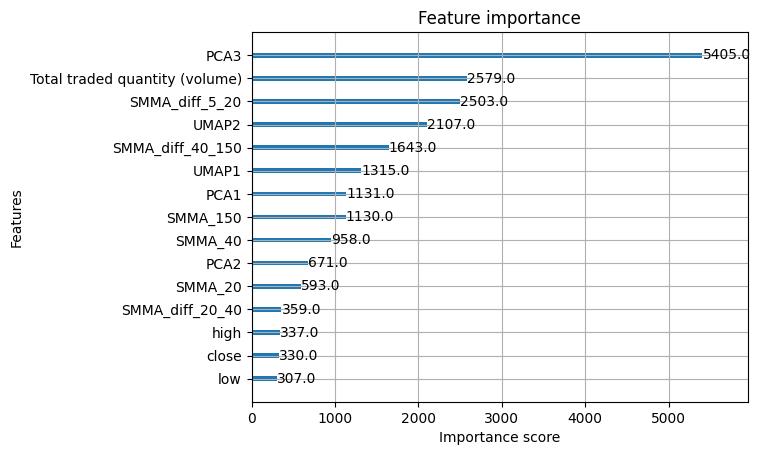

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plot_importance(model, max_num_features=15)
plt.show()


In [ ]:
import joblib
joblib.dump(feature_scaler, "/content/drive/MyDrive/NSE/feature_scaler.pkl")
joblib.dump(target_scaler, "/content/drive/MyDrive/NSE/target_scaler.pkl")
joblib.dump(stock_encoder, "/content/drive/MyDrive/NSE/stock_encoder.pkl")

['/content/drive/MyDrive/NSE/stock_encoder.pkl']

In [ ]:
import pandas as pd
import numpy as np

# ---------- Example Backtesting Function ----------
def backtest_strategy(df, initial_capital=100000):
    """
    df must have: ['date', 'stock_id', 'close', 'pred_price', 'pred_movement']
    """

    df = df.copy()
    df["signal"] = 0  # default hold

    # Generate trading signals
    df.loc[(df["target"] > df["close"]) & (df["Target_Movement"] == 1), "signal"] = 1   # Buy
    df.loc[(df["target"] < df["close"]) & (df["Target_Movement"] == 0), "signal"] = -1  # Sell

    # Shift signals (buy today, action tomorrow)
    df["position"] = df["signal"].shift().fillna(0)

    # Daily returns
    df["return"] = df["close"].pct_change().fillna(0)

    # Strategy returns
    df["strategy_return"] = df["position"] * df["return"]

    # Portfolio growth
    df["portfolio_value"] = initial_capital * (1 + df["strategy_return"]).cumprod()

    # Metrics
    sharpe_ratio = (df["strategy_return"].mean() / df["strategy_return"].std()) * np.sqrt(252)
    cum_return = df["portfolio_value"].iloc[-1] / initial_capital - 1
    max_drawdown = ((df["portfolio_value"].cummax() - df["portfolio_value"]) / df["portfolio_value"].cummax()).max()
    win_rate = (df["strategy_return"] > 0).mean()

    report = {
        "Cumulative Return": round(cum_return * 100, 2),
        "Sharpe Ratio": round(sharpe_ratio, 2),
        "Max Drawdown": round(max_drawdown * 100, 2),
        "Win Rate": round(win_rate * 100, 2)
    }

    return df, report


# ---------- Example Usage ----------
# Assume df_stock is your DataFrame with predictions
df_stock = pd.read_csv("/content/drive/MyDrive/NSE/angelone_historical3_NSE_EGOLD-EQ_ONE_DAY.csv")

# Run backtest
result_df, metrics = backtest_strategy(df)

print(metrics)
result_df[["date","stock_id","close","signal","portfolio_value"]].head()


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)


{'Cumulative Return': np.float64(inf), 'Sharpe Ratio': np.float64(13.85), 'Max Drawdown': 0.0, 'Win Rate': np.float64(50.01)}


,date,stock_id,close,signal,portfolio_value
3607204,2014-07-15,VISAKAIND,21.98,0,100000.000000
1594830,2014-07-15,IOB,72.40,0,100000.000000
1648544,2014-07-15,HAVELLS,244.39,0,100000.000000
1617787,2014-07-15,ESABINDIA,621.35,-1,100000.000000
3726220,2014-07-15,NLCINDIA,93.25,-1,184992.355355


In [49]:
import gradio as gr
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
import joblib
import matplotlib.pyplot as plt

# -----------------------------
# Load trained model and scalers
# -----------------------------
lstm_model = load_model("/content/drive/MyDrive/model/LSTM_model_stock.keras")
feature_scaler = joblib.load("/content/drive/MyDrive/model/feature_scaler.pkl")
target_scaler = joblib.load("/content/drive/MyDrive/model/target_scaler.pkl")
stock_encoder = joblib.load("/content/drive/MyDrive/model/stock_encoder.pkl")

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/all_stocks.csv")

# Map stock IDs to encoded values
label_map = {label: i for i, label in enumerate(stock_encoder.classes_)}
df["stock_id_enc"] = df["stock_id"].map(label_map).fillna(-1).astype(int)

# -----------------------------
# Predict next N days with rolling window
# -----------------------------
def predict_next_days(model, last_known_features, stock_df, stock_id_value, target_scaler, days=22):
    predictions = []
    current_input = last_known_features.copy()
    stock_id_input = np.array([[stock_id_value]])

    # Calculate historical volatility for noise
    hist_std = stock_df['target'].pct_change().std()
    hist_std = hist_std if not np.isnan(hist_std) else 0.01  # fallback

    for _ in range(days):
        # Predict next scaled price
        next_scaled = model.predict([current_input, stock_id_input], verbose=0)
        next_price = target_scaler.inverse_transform(next_scaled)[0, 0]
        predictions.append(next_price)

        # Update rolling input realistically
        new_row = current_input[:, -1, :].copy()
        for i, col_name in enumerate(feature_scaler.feature_names_in_):
            if "close" in col_name.lower():
                new_row[0, i] = next_price
            elif "open" in col_name.lower():
                new_row[0, i] = predictions[-1]  # previous close
            elif "high" in col_name.lower():
                new_row[0, i] = max(new_row[0, i], next_price)
            elif "low" in col_name.lower():
                new_row[0, i] = min(new_row[0, i], next_price)
            else:
                # Add realistic noise based on historical volatility
                new_row[0, i] *= 1 + np.random.normal(0, hist_std)


        # Shift window
        current_input = np.concatenate([current_input[:, 1:, :], new_row.reshape(1, 1, -1)], axis=1)

    return predictions

# -----------------------------
# Gradio prediction function
# -----------------------------
def predict_stock(stock_name):
    stock_df = df[df["stock_id"] == stock_name].copy()
    if stock_df.empty:
        return None, f"Stock '{stock_name}' not found!"

    # Prepare features
    features = stock_df.drop(columns=["stock_id", "date", "target", "Target_Movement"], errors='ignore')
    for col in feature_scaler.feature_names_in_:
        if col not in features.columns:
            features[col] = 0
    X_scaled = feature_scaler.transform(features)

    # Prepare last timesteps for LSTM
    timesteps = lstm_model.input_shape[0][1]
    if X_scaled.shape[0] < timesteps:
        pad = np.zeros((timesteps - X_scaled.shape[0], X_scaled.shape[1]))
        X_scaled = np.vstack([pad, X_scaled])
    last_features = X_scaled[-timesteps:].reshape(1, timesteps, -1)

    stock_id_value = stock_df["stock_id_enc"].iloc[-1]

    # Predict next 100 days
    preds = predict_next_days(lstm_model, last_features, stock_df, stock_id_value, target_scaler, days=22)

    # Create DataFrame
    table_df = pd.DataFrame({
        "Day": [f"Day {i+1}" for i in range(22)],
        "Predicted Price": preds
    })

    # Plot prices
    fig, ax = plt.subplots(figsize=(10,5))
    ax.plot(table_df["Day"], table_df["Predicted Price"], marker='o', color='blue', markersize=3)
    ax.set_title(f"Predicted Prices for {stock_name} (Next 100 Days)")
    ax.set_xlabel("Day")
    ax.set_ylabel("Price")
    ax.grid(True)
    plt.xticks(rotation=45)

    return fig, table_df

# -----------------------------
# Launch Gradio UI
# -----------------------------
stock_list = df["stock_id"].unique().tolist()

gr.Interface(
    fn=predict_stock,
    inputs=gr.Dropdown(stock_list, label="Select Stock"),
    outputs=[gr.Plot(label="Price Chart"), gr.Dataframe(label="Predicted Prices")],
    title="Stock Price Prediction (Next 100 Days)",
    description="Select a stock to see LSTM-predicted prices for the next 100 days."
).launch(debug=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4f47e1a18f41660bc0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/array_slicing.py:63: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/array_slicing.py:63: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/array_slicing.py:63: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/array_slicing.py:63: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/array_slicing.py:63: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/array_slicing.py:63: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype)
/usr/local/lib/p

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7872 <> https://4f47e1a18f41660bc0.gradio.live
